In [1]:
#Some Important Python libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("instructor_effectiveness_dataset_2000_rows - instructor_effectiveness_dataset_2000_rows.csv.csv")

In [3]:
df.head()

,batch_id,instructor_id,course_id,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
0,B_1861,I_044,C_01,0.300000,14.225955,73.546528,0.647423,0.774572,0.790918,0.108414,3.766211,0.533193
1,B_0354,I_119,C_06,0.657220,22.871110,77.312331,0.425098,0.494936,0.998566,0.280550,5.000000,0.734087
2,B_1334,I_050,C_03,0.300000,16.087517,79.563687,0.700000,0.977901,0.807298,0.207013,3.517386,0.681433
3,B_0906,I_024,C_21,0.639507,24.260687,99.295316,0.334657,0.846515,0.544555,0.306395,4.207578,1.000000
4,B_1290,I_001,C_08,0.527302,31.081556,99.393425,0.521099,0.917450,0.865885,0.252289,4.426230,0.696710


## EDA (Exploratory data analysis)

In [5]:
df.shape

(2000, 12)

In [6]:
df.isnull().sum()

batch_id                      0
instructor_id                 0
course_id                     0
completion_rate               0
avg_score_improvement         0
avg_quiz_score                0
dropout_rate                  0
avg_watch_time                0
assignment_submission_rate    0
forum_activity_rate           0
avg_feedback_score            0
feedback_response_rate        0
dtype: int64

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   batch_id                    2000 non-null   object 
 1   instructor_id               2000 non-null   object 
 2   course_id                   2000 non-null   object 
 3   completion_rate             2000 non-null   float64
 4   avg_score_improvement       2000 non-null   float64
 5   avg_quiz_score              2000 non-null   float64
 6   dropout_rate                2000 non-null   float64
 7   avg_watch_time              2000 non-null   float64
 8   assignment_submission_rate  2000 non-null   float64
 9   forum_activity_rate         2000 non-null   float64
 10  avg_feedback_score          2000 non-null   float64
 11  feedback_response_rate      2000 non-null   float64
dtypes: float64(9), object(3)
memory usage: 187.6+ KB


In [8]:
df.describe()

,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,0.602808,27.035844,77.956126,0.394883,0.776515,0.753188,0.250300,4.207134,0.736519
std,0.159667,5.716641,10.695618,0.162747,0.145231,0.148058,0.100640,0.419209,0.149412
min,0.300000,6.159240,40.386725,0.020000,0.287440,0.251111,0.000000,2.639915,0.259935
25%,0.489260,23.124673,70.897590,0.280035,0.675076,0.652110,0.179845,3.918986,0.633293
50%,0.603091,26.938629,78.020567,0.394820,0.780330,0.756380,0.249771,4.205989,0.737213
75%,0.712797,30.885600,85.444286,0.511432,0.894242,0.856458,0.319204,4.503437,0.845876
max,0.980000,40.000000,100.000000,0.700000,1.000000,1.000000,0.641111,5.000000,1.000000


In [9]:
df['instructor_id'].nunique()

120

In [10]:
df['course_id'].nunique()  

25

array([[<Axes: title={'center': 'completion_rate'}>,
        <Axes: title={'center': 'avg_score_improvement'}>,
        <Axes: title={'center': 'avg_quiz_score'}>],
       [<Axes: title={'center': 'dropout_rate'}>,
        <Axes: title={'center': 'avg_watch_time'}>,
        <Axes: title={'center': 'assignment_submission_rate'}>],
       [<Axes: title={'center': 'forum_activity_rate'}>,
        <Axes: title={'center': 'avg_feedback_score'}>,
        <Axes: title={'center': 'feedback_response_rate'}>]], dtype=object)

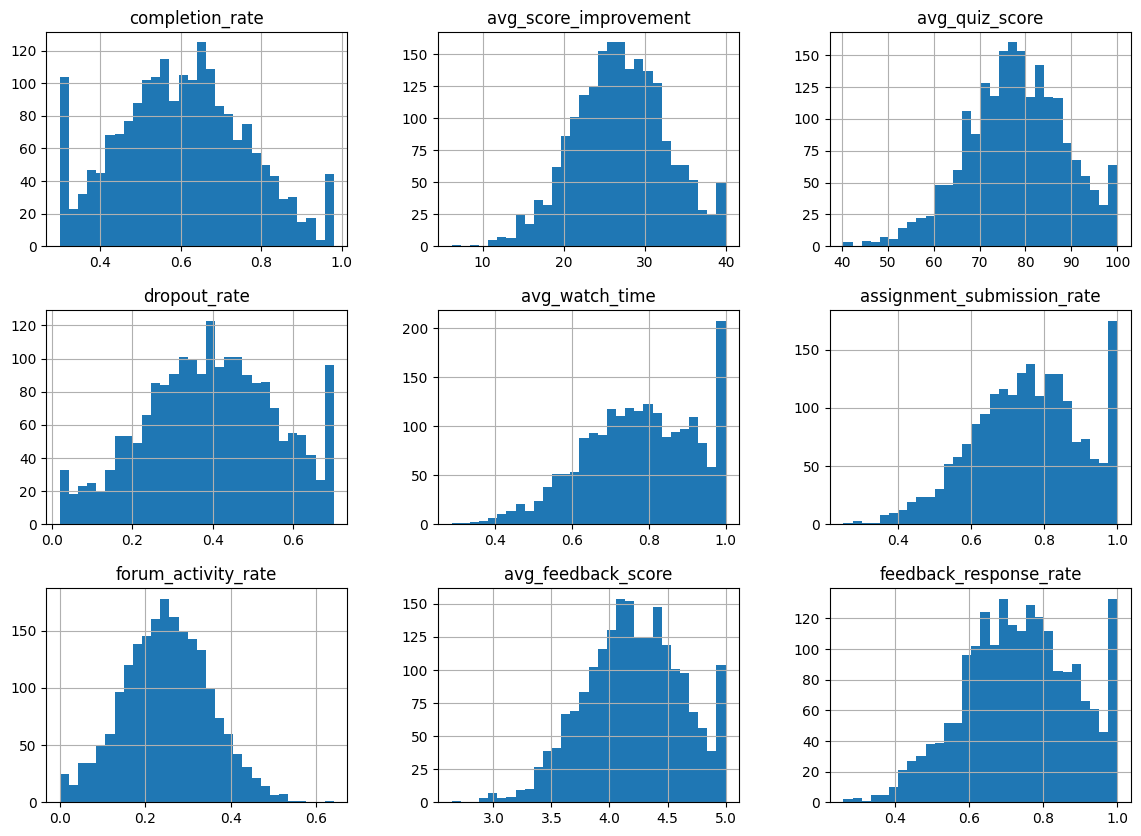

In [11]:
df.hist(figsize=(14,10), bins=30)

<Axes: >

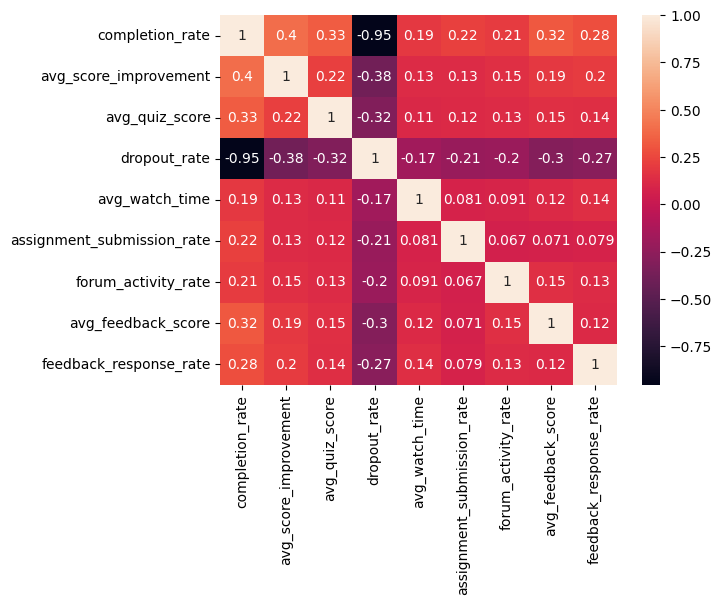

In [12]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

In [13]:
#Using MinMaxScaler for normalization
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df['score_imp_norm'] = scaler.fit_transform(df[['avg_score_improvement']])
df['quiz_norm'] = scaler.fit_transform(df[['avg_quiz_score']])
df['feedback_norm'] = (df['avg_feedback_score'] - 1) / 4

In [14]:
df.head()

,batch_id,instructor_id,course_id,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate,score_imp_norm,quiz_norm,feedback_norm
0,B_1861,I_044,C_01,0.300000,14.225955,73.546528,0.647423,0.774572,0.790918,0.108414,3.766211,0.533193,0.238373,0.556249,0.691553
1,B_0354,I_119,C_06,0.657220,22.871110,77.312331,0.425098,0.494936,0.998566,0.280550,5.000000,0.734087,0.493839,0.619419,1.000000
2,B_1334,I_050,C_03,0.300000,16.087517,79.563687,0.700000,0.977901,0.807298,0.207013,3.517386,0.681433,0.293382,0.657185,0.629347
3,B_0906,I_024,C_21,0.639507,24.260687,99.295316,0.334657,0.846515,0.544555,0.306395,4.207578,1.000000,0.534901,0.988179,0.801895
4,B_1290,I_001,C_08,0.527302,31.081556,99.393425,0.521099,0.917450,0.865885,0.252289,4.426230,0.696710,0.736459,0.989825,0.856558


In [15]:
# effectiveness_score = (
#     0.25 × completion_rate          +   # 25% weightage
#     0.20 × score_improvement        +   # 20% weightage
#     0.15 × quiz_score               +   # 15% weightage
#     0.15 × feedback_score           +   # 15% weightage
#     0.10 × watch_time               +   # 10% weightage
#     0.10 × assignment_submission    +   # 10% weightage
#     0.05 × forum_activity           -   # 5%  weightage
#     0.20 × dropout_rate                 # 20% PENALTY
# )

# All weights add up to:
# 0.25 + 0.20 + 0.15 + 0.15 + 0.10 + 0.10 + 0.05 = 1.00 
# Minus the penalty separately 
# Weightage are choosing by which feature is more useful or which is not 

In [16]:
#Building Weight Scores
df['effectiveness_score'] = (
    0.25 * df['completion_rate'] +
    0.20 * df['score_imp_norm'] +
    0.15 * df['quiz_norm'] +
    0.15 * df['feedback_norm'] +
    0.10 * df['avg_watch_time'] +
    0.10 * df['assignment_submission_rate'] +
    0.05 * df['forum_activity_rate'] -
    0.20 * df['dropout_rate']        
)

In [17]:
df.head()

,batch_id,instructor_id,course_id,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate,score_imp_norm,quiz_norm,feedback_norm,effectiveness_score
0,B_1861,I_044,C_01,0.300000,14.225955,73.546528,0.647423,0.774572,0.790918,0.108414,3.766211,0.533193,0.238373,0.556249,0.691553,0.342330
1,B_0354,I_119,C_06,0.657220,22.871110,77.312331,0.425098,0.494936,0.998566,0.280550,5.000000,0.734087,0.493839,0.619419,1.000000,0.584344
2,B_1334,I_050,C_03,0.300000,16.087517,79.563687,0.700000,0.977901,0.807298,0.207013,3.517386,0.681433,0.293382,0.657185,0.629347,0.375527
3,B_0906,I_024,C_21,0.639507,24.260687,99.295316,0.334657,0.846515,0.544555,0.306395,4.207578,1.000000,0.534901,0.988179,0.801895,0.622863
4,B_1290,I_001,C_08,0.527302,31.081556,99.393425,0.521099,0.917450,0.865885,0.252289,4.426230,0.696710,0.736459,0.989825,0.856558,0.642803


## Aggregrate all features to instructor level

In [19]:
instructor_df = df.groupby('instructor_id').agg(
    completion_rate = ('completion_rate', 'mean'),
    dropout_rate = ('dropout_rate', 'mean'),
    avg_score_improvement = ('avg_score_improvement', 'mean'),
    avg_quiz_score = ('avg_quiz_score', 'mean'),
    avg_watch_time = ('avg_watch_time', 'mean'),
    assignment_submission_rate = ('assignment_submission_rate', 'mean'),
    forum_activity_rate = ('forum_activity_rate', 'mean'),
    avg_feedback_score = ('avg_feedback_score', 'mean'),
    feedback_response_rate = ('feedback_response_rate', 'mean'),
    num_batches = ('batch_id', 'count'),         # important extra feature!
    effectiveness_score = ('effectiveness_score', 'mean')
).reset_index()

### Creating Tiers using percentile 
Ex: score < 0.4 = Low

In [21]:
p33 = instructor_df['effectiveness_score'].quantile(0.33)
p66 = instructor_df['effectiveness_score'].quantile(0.66)

def assign_tier(score):
    if score <= p33:
        return 'Low'
    elif score <= p66:
        return 'Medium'
    else:
        return 'High'

instructor_df['tier'] = instructor_df['effectiveness_score'].apply(assign_tier)
instructor_df['tier'].value_counts()
# Low: 40, Medium: 39, High: 41  (almost perfectly balanced)

tier
High      41
Low       40
Medium    39
Name: count, dtype: int64

# Building ML Model

In [23]:
features = ['completion_rate', 'dropout_rate', 'avg_score_improvement',
            'avg_quiz_score', 'avg_watch_time', 'assignment_submission_rate',
            'forum_activity_rate', 'avg_feedback_score', 
            'feedback_response_rate', 'num_batches']

X = instructor_df[features]
y = instructor_df['tier']

#### using StandardScaler before Train_test_split for normalize the features so if in future we need to change the model to Logistic and other than we can easily do it 

In [25]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y)
# stratify=y ensures each tier is proportionally represented in train/test

## Using RandomForest because it handled non-linearity and give importance to features and working good on small data

In [27]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100, 
    random_state=42, 
    class_weight='balanced'   
)
model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [28]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
print("Accuracy Score :", accuracy_score(y_test, y_pred))

              precision    recall  f1-score   support

        High       1.00      0.88      0.93         8
         Low       1.00      0.88      0.93         8
      Medium       0.80      1.00      0.89         8

    accuracy                           0.92        24
   macro avg       0.93      0.92      0.92        24
weighted avg       0.93      0.92      0.92        24

Accuracy Score : 0.9166666666666666


### The model achieves 92% accuracy, which may seem surprisingly high.
this is expected and here is why:
The tiers (Low, Medium, High) were defined by us using the same 
features that the model is now trained on. So the model is essentially 
learning our own formula back not discovering something new.
This is called **circular reasoning** we created the labels 
from the data, then trained the model on the same data.

Text(0.5, 1.0, 'Confusion Matrix')

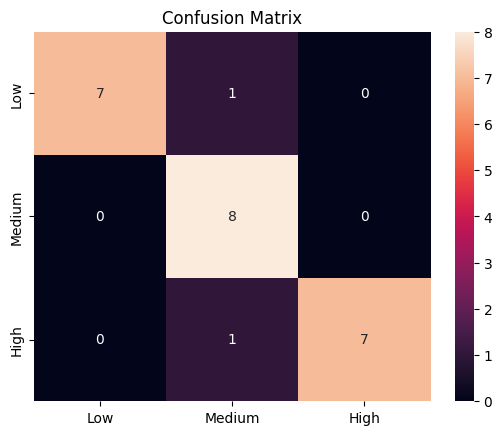

In [30]:
cm = confusion_matrix(y_test, y_pred, labels=['Low','Medium','High'])
sns.heatmap(cm, annot=True, fmt='d', 
            xticklabels=['Low','Medium','High'],
            yticklabels=['Low','Medium','High'])
plt.title("Confusion Matrix")

## Cross Validation (5-Fold)
A single train-test split can be misleading with small datasets.
Since we only have 120 instructor records, the result could 
vary significantly depending on which 24 instructors 
randomly end up in the test set.

In [32]:
from sklearn.model_selection import cross_val_score
cv = cross_val_score(model, X_scaled, y, cv=5, scoring='f1_macro')
print("CV F1 scores:", cv.round(3))
print("Mean:", cv.mean().round(3))   

CV F1 scores: [0.866 0.917 0.875 0.837 0.956]
Mean: 0.89


## Feature Importance Analysis
Feature importance tells us which features the Random Forest relied on most when making predictions.
This is one of the most valuable outputs of the model it tells us WHAT actually drives instructor effectiveness.

**Results:**
1. completion_rate          → 33% (most important)
2. dropout_rate             → 24%
3. avg_score_improvement    → 13%
4. avg_quiz_score           → 10%
5. avg_feedback_score       →  5%
6. feedback_response_rate   →  4%
7. avg_watch_time           →  4%
8. forum_activity_rate      →  3%
9. assignment_submission    →  2%
10. num_batches             →  1% (least important)

Text(0.5, 0, 'Importance Score')

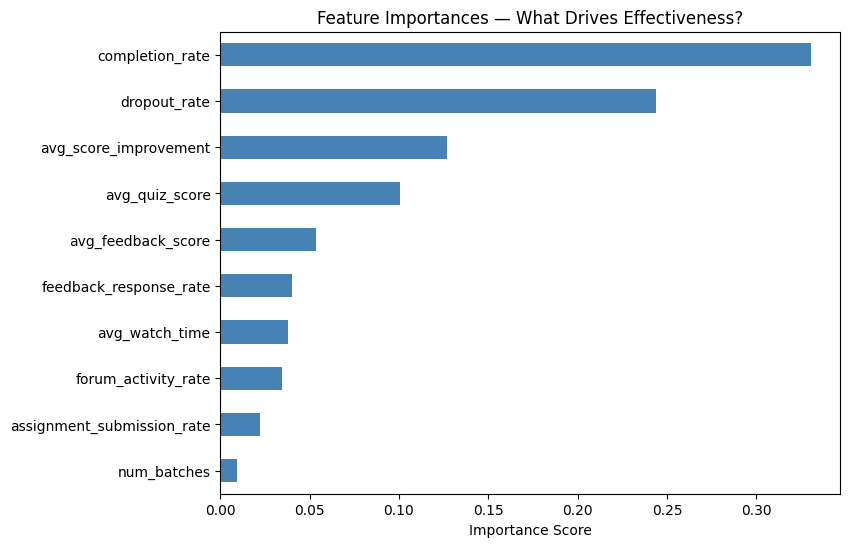

In [34]:
importances = pd.Series(model.feature_importances_, index=features)
importances.sort_values().plot(kind='barh', figsize=(8,6), color='steelblue')
plt.title("Feature Importances — What Drives Effectiveness?")
plt.xlabel("Importance Score")

### completion_rate and dropout_rate together account for over 55% of the model's decisions. 

# Analysis Questions and Answers

### Q1. Which features most influenced effectiveness?
    
completion_rate and dropout_rate because they directly capture whether students stayed and succeeded.

### Q2. Which variables could be misleading?

avg_feedback_score : easy instructors get better ratings. 
avg_quiz_score : varies with course difficulty, not just instructor quality. 
forum_activity_rate : depends on course type, not just the instructor.

### Q3. How could this model fail in real-world usage?

Labels are self-created the model learns your assumptions back. If a course is inherently hard, the instructor will always score Low. Small batch instructors have unreliable averages.

### Q4. What additional data would help?

Course difficulty rating, learner demographics, instructor experience (years), salary/incentive data, repeat enrollment rates, job placement rates after course completion.

### Q5. Should this be used for performance evaluation?

Not alone. It should be one input in a human-led review process. Using it for firing decisions would be ethically risky and legally questionable because labels are self-defined and contextual factors like course difficulty are unaccounted for.